# K-Means

En este notebook vamos a utilizar el algoritmo K-Means para agrupar e identificar distintos sectores de un grupo de clientes de una empresa 

### SETUP
Como siempre, instalamos e importamos las dependencias necesarias para el proyecto y cargamos el dataset

In [2]:
!pip install -q numpy
!pip install -q pandas
!pip install -q matplotlib
!pip install -q scikit-learn
!pip install -q plotly
!pip install -q seaborn

In [21]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans 
from sklearn.datasets import make_blobs 
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import seaborn as sns

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%204/data/Cust_Segmentation.csv")

## Estudio del Dataset

Primero limpiemos el dataset de NANs, luego analicemos los tipos e imprimamos un sample

In [22]:
df = df.dropna()
print("----------------------TIPOS--------------")
print(df.dtypes)
print("----------------------SAMPLES--------------")
df.sample(4)

----------------------TIPOS--------------
Customer Id          int64
Age                  int64
Edu                  int64
Years Employed       int64
Income               int64
Card Debt          float64
Other Debt         float64
Defaulted          float64
Address             object
DebtIncomeRatio    float64
dtype: object
----------------------SAMPLES--------------


,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,Address,DebtIncomeRatio
302,303,23,1,5,17,0.302,1.041,0.0,NBA002,7.9
733,734,41,2,8,43,0.086,0.215,0.0,NBA021,0.7
167,168,30,1,11,27,0.074,0.169,0.0,NBA009,0.9
657,658,37,3,16,50,7.320,10.980,1.0,NBA014,36.6


Podemos ver que tenemos un valor categorico (Address) y, por otro lado, valores de distintas magnitudes que deberíamos normalizar. 

## Preprocesamiento
La columna no-numerica no vamos a utilizarla y el ID solo le aportaria ruido al modelo, por lo tanto podemos remover estas variables y luego normalizar el resto

In [ ]:
# Eliminamos la columna no-numerica
df = df.drop(['Address'], axis=1)

# Para el modelo no necesitamos el ID de cliente
x = df.drop(['Customer Id'], axis=1)

#Normalizamos valores numericos
x_normalized = StandardScaler().fit_transform(x)

## Creacion del Modelo

Ahora si podemos armar el modelo con nuestro algoritmo K-Means, recordemos que nuestro [Parametro](README.md/#parametros) nos pide definir el valor K.

In [24]:
# Definimos K y construimos el modelo
K = 3
k_means = KMeans(init="k-means++", n_clusters=K,n_init=12)

# Utilizamos el modelo para agrupar nuestro dataset
k_means.fit(x_normalized)


KMeans(n_clusters=3, n_init=12)

## Analisis de los Resultados

Ahora bien, teniendo nuestro modelo podriamos analizar los agrupamientos obtenidos, esto es posible ya que nuestro modelo nos otorga *labels* que indican cada cluster. 

In [25]:
# A cada cliente le agregamos su numero de cluster 
df["Cluster"] = k_means.labels_

# Agrupamos por cluster y calculamos la media
df.groupby('Cluster').mean()

,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
Cluster,,,,,,,,,
0,416.848000,43.112000,1.960000,16.904000,96.056000,4.172896,7.811616,0.208000,14.398400
1,438.731884,33.727053,1.601449,7.644928,36.246377,0.788126,1.748710,0.000000,7.581884
2,419.763975,31.366460,1.850932,3.689441,30.484472,1.488199,2.734901,0.975155,13.936025


Con esto logramos reagrupar el dataset en 3 clusters, con una media de los valores de todos los clientes pertenecientes a los mismos. 
<br> Podemos graficar distintos tipos de perfiles en base a los clusters

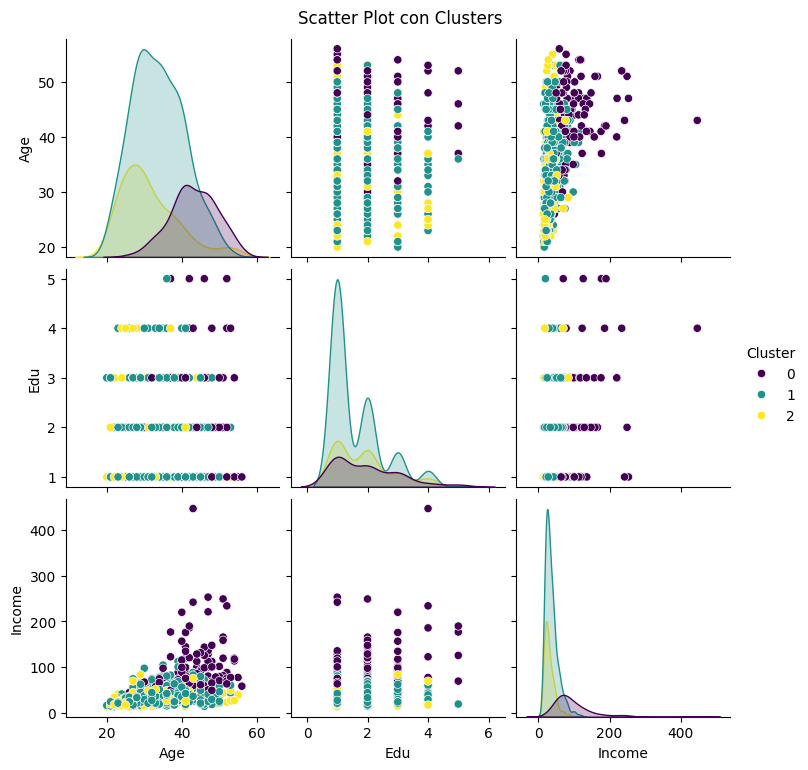

In [ ]:
df_sub = df[['Age', 'Edu','Income','Cluster']].copy() 
sns.pairplot(df_sub, hue='Cluster', palette='viridis', diag_kind='kde') 
plt.suptitle('Scatter Plots y KDEs', y=1.02)
plt.show()

Efectivamente viendo la distribución de los datos podemos identificar los siguientes patrones en los grupos:
-   Salarios altos, edad avanzada (Violeta)
-   Salarios medios, edad media (Azul)
-   Salarios bajos, edad joven (Amarillo)
